# Power Dissipation Index (PDI) demo

This notebook demonstrates the `tcpyPI.power_dissipation_index()` utility using:

- **Observed best-track intensity** for Hurricane Milton (2024) from IBTrACS (hardcoded below, so the notebook is self-contained)
- A worked example storm: **Hurricane Milton (2024)**

PDI is defined (e.g., [Emanuel 2007](https://journals.ametsoc.org/view/journals/clim/20/22/2007jcli1571.1.xml)) as:

$$\mathrm{PDI} = \int V_{\max}(t)^3\,dt$$

## Important scientific caveats

- **PDI is a track/intensity-history metric**. In standard usage, $V_{\max}(t)$ is realized storm intensity (best-track, model TC tracker, etc.).
- In this notebook, PDI is computed from **IBTrACS `usa_wind`** (knots).
- PDI is sensitive to **sampling cadence and missing data**. Here we infer $\Delta t$ from the IBTrACS timestamps and use `nan_policy="omit"`.


## 0) Setup

In [1]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
repo_root = None
for cand in [here] + list(here.parents):
    if (cand / "src" / "tcpyPI").is_dir():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError(
        "Could not locate repo root (expected src/tcpyPI). "
        "Run from within the repo or install with `pip install -e .`."
    )

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import tcpyPI

print("tcpyPI from:", tcpyPI.__file__)


tcpyPI from: /home/dgilford/tcpyPI/src/tcpyPI/__init__.py


## 1) Hurricane Milton (2024) best track

The IBTrACS best-track intensity is hardcoded below (extracted from IBTrACS NA v04r01), so no download is needed.

In [2]:
import numpy as np

# Hurricane Milton (2024) best track from IBTrACS (North Atlantic v04r01),
# hardcoded here so this notebook is self-contained (no external download).
# usa_wind is the ATCF best-track maximum sustained wind (knots).
_TIMES = ['2024-10-04T18:00', '2024-10-04T21:00', '2024-10-05T00:00', '2024-10-05T03:00', '2024-10-05T06:00', '2024-10-05T09:00', '2024-10-05T12:00', '2024-10-05T15:00', '2024-10-05T18:00', '2024-10-05T21:00', '2024-10-06T00:00', '2024-10-06T03:00', '2024-10-06T06:00', '2024-10-06T09:00', '2024-10-06T12:00', '2024-10-06T15:00', '2024-10-06T18:00', '2024-10-06T21:00', '2024-10-07T00:00', '2024-10-07T03:00', '2024-10-07T06:00', '2024-10-07T09:00', '2024-10-07T12:00', '2024-10-07T15:00', '2024-10-07T18:00', '2024-10-07T20:00', '2024-10-07T21:00', '2024-10-08T00:00', '2024-10-08T03:00', '2024-10-08T06:00', '2024-10-08T09:00', '2024-10-08T12:00', '2024-10-08T15:00', '2024-10-08T18:00', '2024-10-08T21:00', '2024-10-08T22:05', '2024-10-09T00:00', '2024-10-09T02:05', '2024-10-09T03:00', '2024-10-09T06:00', '2024-10-09T08:25', '2024-10-09T09:00', '2024-10-09T12:00', '2024-10-09T15:00', '2024-10-09T18:00', '2024-10-09T21:00', '2024-10-10T00:00', '2024-10-10T00:30', '2024-10-10T03:00', '2024-10-10T06:00', '2024-10-10T09:00', '2024-10-10T12:00', '2024-10-10T15:00', '2024-10-10T18:00', '2024-10-10T21:00', '2024-10-11T00:00', '2024-10-11T03:00', '2024-10-11T06:00', '2024-10-11T09:00', '2024-10-11T12:00', '2024-10-11T15:00', '2024-10-11T18:00']
t = np.array(_TIMES, dtype='datetime64[m]')
lat = np.array([21.0, 20.8, 20.8, 21.0, 21.4, 21.7, 22.0, 22.3, 22.5, 22.6, 22.7, 22.7, 22.6, 22.5, 22.5, 22.5, 22.5, 22.5, 22.5, 22.3, 22.1, 21.9, 21.8, 21.7, 21.7, 21.8, 21.8, 21.8, 21.8, 21.9, 22.2, 22.5, 22.5, 22.5, 22.7, 22.8, 23.0, 23.3, 23.4, 23.8, 24.3, 24.4, 25.0, 25.7, 26.3, 26.8, 27.3, 27.4, 27.8, 28.1, 28.6, 29.0, 29.3, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5, 29.4, 29.3])
lon = np.array([-94.6, -94.9, -95.2, -95.3, -95.4, -95.5, -95.5, -95.5, -95.5, -95.5, -95.5, -95.4, -95.2, -95.0, -94.8, -94.5, -94.1, -93.7, -93.4, -93.1, -92.9, -92.6, -92.2, -91.8, -91.3, -90.9, -90.7, -90.4, -89.9, -89.5, -89.1, -88.8, -88.4, -88.0, -87.4, -87.2, -86.9, -86.6, -86.5, -85.9, -85.4, -85.3, -84.8, -84.4, -84.0, -83.4, -82.7, -82.6, -82.1, -81.3, -80.4, -79.5, -78.6, -77.5, -76.3, -75.0, -73.7, -72.4, -70.9, -69.3, -67.6, -65.9])
vmax_kt = np.array([30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 33.0, 35.0, 35.0, 35.0, 40.0, 45.0, 50.0, 55.0, 63.0, 70.0, 73.0, 75.0, 83.0, 90.0, 105.0, 120.0, 135.0, 150.0, 155.0, 153.0, 145.0, 135.0, 125.0, 125.0, 125.0, 133.0, 140.0, 144.0, 145.0, 140.0, 135.0, 136.0, 140.0, 140.0, 139.0, 135.0, 125.0, 115.0, 110.0, 105.0, 100.0, 86.0, 70.0, 68.0, 65.0, 63.0, 60.0, 60.0, 60.0, 58.0, 55.0, 55.0, 55.0, 53.0, 50.0])

print('Milton (2024): %d fixes, %s to %s, peak %.0f kt'
      % (t.size, t[0], t[-1], vmax_kt.max()))

Milton (2024): 62 fixes, 2024-10-04T18:00 to 2024-10-11T18:00, peak 155 kt


## 2) Extract track, intensity, and compute PDI

We use IBTrACS `usa_wind` (typically ATCF best-track intensity) in **knots**.

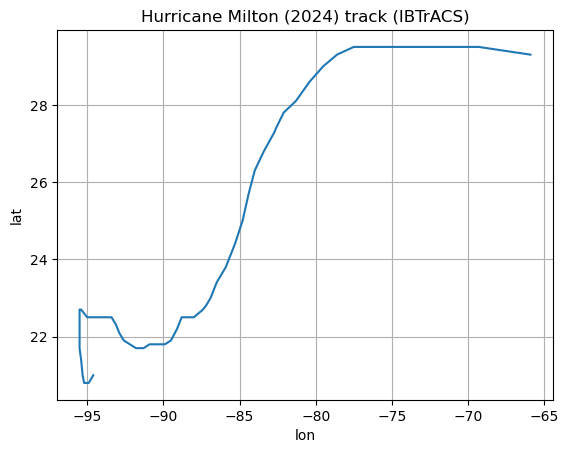

In [3]:
plt.plot(lon, lat)
plt.title('Hurricane Milton (2024) track (IBTrACS)')
plt.xlabel('lon')
plt.ylabel('lat')
plt.grid(True)

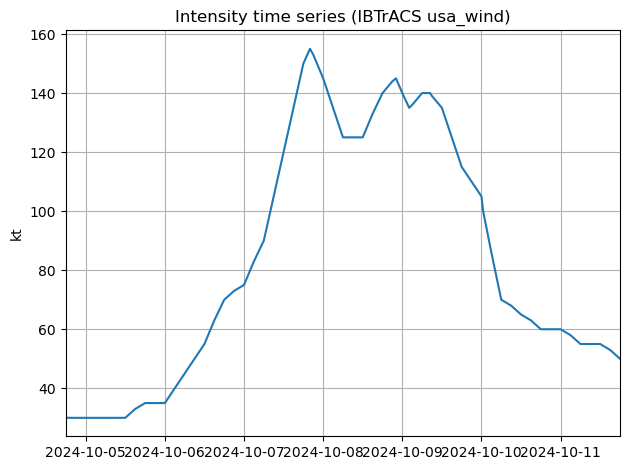

In [4]:
plt.plot(t, vmax_kt)
plt.title('Intensity time series (IBTrACS usa_wind)')
plt.ylabel('kt')
plt.xlim([t[0],t[-1]])
plt.grid(True)

plt.tight_layout()
plt.show()


For the discrete time series, we approximate the integral with a Riemann sum:

$$\mathrm{PDI} \approx \sum_i V_{\max,i}^3\,\Delta t_i$$

where $\Delta t_i$ is inferred from time differences.

In [5]:
# Build dt array (hours) aligned with vmax; forward differences, last = previous.
dt_h = np.diff(t).astype('timedelta64[m]').astype(float) / 60.0
if dt_h.size == 0:
    raise ValueError('Storm has too few points to compute PDI.')
dt_h = np.concatenate([dt_h[:1], dt_h])
dt_h[-1] = dt_h[-2]

print('Fixes:', t.size, '| range:', t[0], 'to', t[-1],
      '| typical dt (h):', float(np.nanmedian(dt_h)))

pdi_si = tcpyPI.power_dissipation_index(vmax_kt, dt_h, wind_units='kt', dt_units='h', nan_policy='omit')
pdi_scaled = tcpyPI.power_dissipation_index(vmax_kt, dt_h, wind_units='kt', dt_units='h', formulation='e05_1e11', nan_policy='omit')

print('PDI (e05_si)  :', pdi_si)
print('PDI (e05_1e11):', pdi_scaled)

Fixes: 62 | range: 2024-10-04T18:00 to 2024-10-11T18:00 | typical dt (h): 3.0
PDI (e05_si)  : 85400111827.41266
PDI (e05_1e11): 0.8540011182741266


### The two PDI values and the `e05_1e11` scaling

The two calls return the **same quantity in different units** — they always differ by **exactly a factor of $10^{11}$** (a rescaling, not a different calculation):

- **`e05_si`** — the raw SI sum, $\mathrm{PDI}=\sum_i V_i^3\,\Delta t_i$ with $V$ in m/s and $\Delta t$ in seconds. Units are **$\mathrm{m^3\,s^{-2}}$** (since $(\mathrm{m/s})^3\cdot\mathrm{s}=\mathrm{m^3\,s^{-2}}$). For Milton, $\approx 8.5\times10^{10}\ \mathrm{m^3\,s^{-2}}$.
- **`e05_1e11`** — the identical value divided by $10^{11}$ (a display convenience), so $\approx 0.85$.

**Why divide by $10^{11}$?** Both a single intense storm's lifetime PDI and the basin-annual PDI summed over all storms (Emanuel 2005) are of order $10^{10}$–$10^{11}\ \mathrm{m^3\,s^{-2}}$. Dividing by $10^{11}$ maps them onto an **$O(1)$ axis**, which is convenient for plotting PDI time series or comparing storms and seasons. Milton's $\approx 0.85$ is a sensible magnitude for a single, exceptionally intense (Cat-5) storm — a large fraction of a typical basin-season total.

Landing at $O(1)$ after the $/10^{11}$ scaling is also a quick **unit sanity check**: a value many orders of magnitude off (e.g. $10^{-6}$ or $10^{6}$) would flag a unit slip — for instance leaving the wind in knots or $\Delta t$ in hours instead of converting to m/s and seconds.

## Notes on options

`power_dissipation_index` supports:
- `wind_units`: `"m/s"` or `"kt"`
- `dt_units`: `"s"` or `"h"`
- `formulation`: `"e05_si"` (raw) or `"e05_1e11"` (scaled)
- `nan_policy`: `"propagate"` (default) or `"omit"`

`dt` can be a scalar (constant timestep) or an array broadcastable to `vmax` (variable timestep).